# Dermascope-VLM — Model Evaluation
Loads best CNN, ResNet-50, and Swin-T checkpoints and evaluates on the test set.

In [2]:
import sys
import os
import re
import json
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
with open(os.path.join(ROOT, 'configs', 'ablation_notebooks.json'), 'r') as f:
    NB_CFG = json.load(f)
EVAL_CFG = NB_CFG['evaluate_best_image_models']

from dataset import get_loaders, NUM_CLASSES, CLASS_NAMES

def load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

cnn_mod = load_module('custom_cnn', os.path.join(ROOT, EVAL_CFG['modules']['cnn']))
resnet_mod = load_module('resnet50', os.path.join(ROOT, EVAL_CFG['modules']['resnet50']))
swin_mod = load_module('swin_t', os.path.join(ROOT, EVAL_CFG['modules']['swin_t']))

custom_CNN = cnn_mod.custom_CNN
build_resnet50 = resnet_mod.build_resnet50
build_swin_tiny = swin_mod.build_swin_tiny

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
_, _, test_loader = get_loaders()
print(f'Test batches: {len(test_loader)}')

Test batches: 32


In [4]:
CKPTS = {name: os.path.join(ROOT, rel_path) for name, rel_path in EVAL_CFG['checkpoints'].items()}

for name, path in CKPTS.items():
    status = 'OK' if os.path.exists(path) else 'NOT FOUND'
    print(f'{name}: {status} — {path}')

CNN: OK — /home/b5ng/private/Dermascope-VLM/results/cnn/best_model/best_cnn.pth
ResNet-50: OK — /home/b5ng/private/Dermascope-VLM/results/resnet50/best_model/best_resnet50.pth
Swin-T: OK — /home/b5ng/private/Dermascope-VLM/results/swin_t/best_model/best_swin_t.pth


In [5]:
def load_model(model, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)
    model.eval()
    return model

cnn = load_model(custom_CNN(num_classes=NUM_CLASSES),      CKPTS['CNN'])
resnet = load_model(build_resnet50(num_classes=NUM_CLASSES),  CKPTS['ResNet-50'])
swin_t = load_model(build_swin_tiny(num_classes=NUM_CLASSES), CKPTS['Swin-T'])

models = {'CNN': cnn, 'ResNet-50': resnet, 'Swin-T': swin_t}
print('All models loaded.')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /tmp/xdg-cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 348MB/s]


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

All models loaded.


## Evaluate All Models

In [6]:
def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_metrics(model, loader, device, num_classes, class_names):
    labels, preds, probs = get_predictions(model, loader, device)
    label_matrix = np.eye(num_classes)[labels]
    return {
        'labels': labels,
        'preds': preds,
        'probs': probs,
        'accuracy': (preds == labels).mean() * 100,
        'macro_auc': roc_auc_score(label_matrix, probs, average='macro', multi_class='ovr'),
        'micro_auc': roc_auc_score(label_matrix, probs, average='micro', multi_class='ovr'),
        'per_class_auc': roc_auc_score(label_matrix, probs, average=None,   multi_class='ovr'),
        'report': classification_report(labels, preds, target_names=class_names, zero_division=0),
    }

results = {}
for name, model in models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    results[name] = compute_metrics(model, test_loader, device, NUM_CLASSES, CLASS_NAMES)
    print('done')

Evaluating CNN... done
Evaluating ResNet-50... done
Evaluating Swin-T... done


## Summary Table — Accuracy, Macro AUC, Micro AUC

In [7]:
print(f"{'Model':<12}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 50)
for name, r in results.items():
    print(f"{name:<12}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}")

print(f"\nPer-class AUC")
print(f"{'Class':<25}", end='')
for name in results:
    print(f"  {name:>10}", end='')
print()
print('-' * 60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:<25}", end='')
    for r in results.values():
        print(f"  {r['per_class_auc'][i]:>10.4f}", end='')
    print()

Model           Accuracy   Macro AUC   Micro AUC
--------------------------------------------------
CNN               72.75%      0.8963      0.9542
ResNet-50         87.82%      0.9768      0.9876
Swin-T            86.43%      0.9761      0.9878

Per-class AUC
Class                             CNN   ResNet-50      Swin-T
------------------------------------------------------------
MEL                            0.8781      0.9395      0.9408
NV                             0.8920      0.9666      0.9651
BCC                            0.9298      0.9965      0.9965
AKIEC                          0.9188      0.9756      0.9693
BKL                            0.8268      0.9600      0.9622
DF                             0.8425      0.9998      0.9987
VASC                           0.9861      0.9995      0.9999


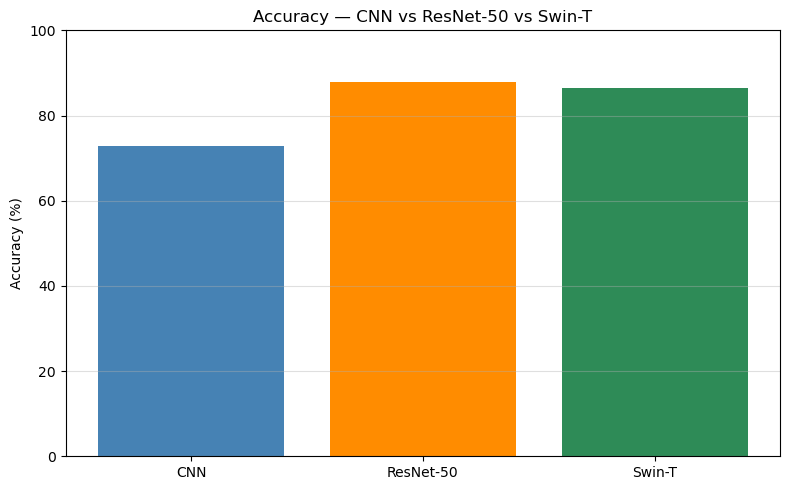

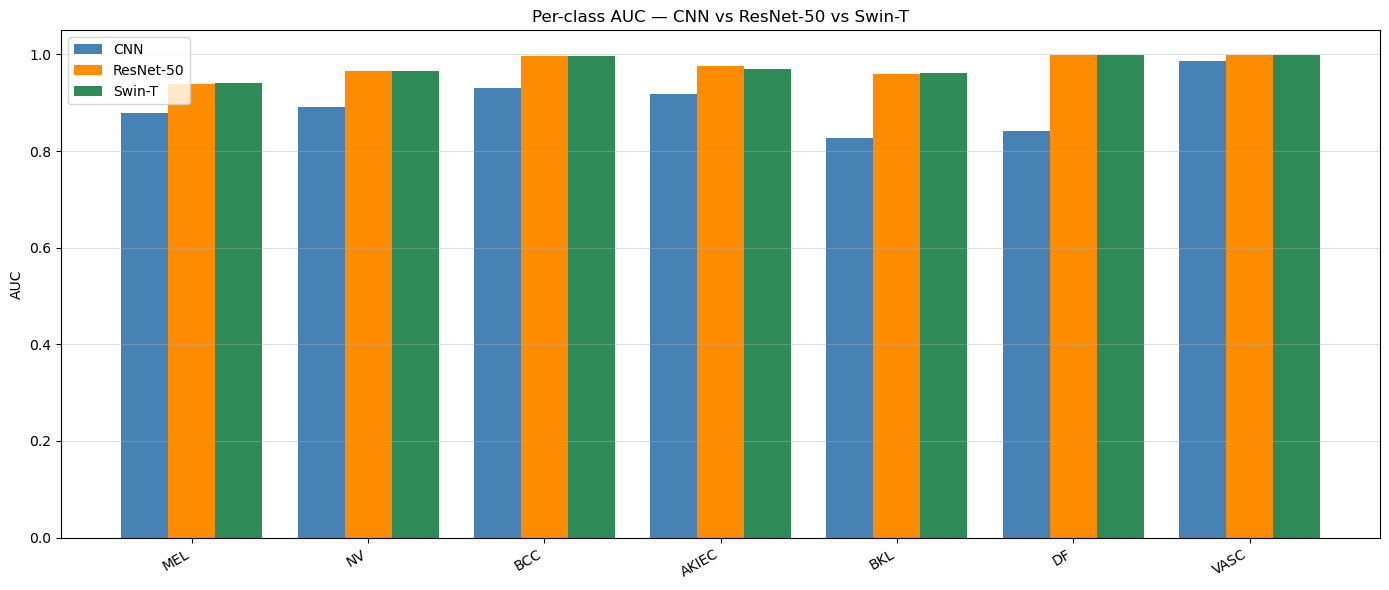

In [8]:
model_names = list(results.keys())
colors      = ['steelblue', 'darkorange', 'seagreen']

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_names, [results[m]['accuracy'] for m in model_names], color=colors)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy — CNN vs ResNet-50 vs Swin-T')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Per-class AUC grouped bar chart
x     = np.arange(len(CLASS_NAMES))
width = 0.8 / len(model_names)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name]['per_class_auc'][j] for j in range(len(CLASS_NAMES))]
    ax.bar(x + i * width - (len(model_names) - 1) * width / 2, vals, width, label=name, color=color)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Per-class AUC — CNN vs ResNet-50 vs Swin-T')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Classification Reports

In [9]:
for name, r in results.items():
    print(f'\n--- {name} ---')
    print(r['report'])


--- CNN ---
              precision    recall  f1-score   support

         MEL       0.51      0.38      0.44       112
          NV       0.80      0.93      0.86       671
         BCC       0.42      0.31      0.36        52
       AKIEC       0.48      0.34      0.40        32
         BKL       0.45      0.30      0.36       110
          DF       0.00      0.00      0.00        11
        VASC       0.00      0.00      0.00        14

    accuracy                           0.73      1002
   macro avg       0.38      0.32      0.34      1002
weighted avg       0.68      0.73      0.70      1002


--- ResNet-50 ---
              precision    recall  f1-score   support

         MEL       0.73      0.71      0.72       112
          NV       0.92      0.95      0.94       671
         BCC       0.88      0.87      0.87        52
       AKIEC       0.65      0.81      0.72        32
         BKL       0.81      0.61      0.69       110
          DF       0.79      1.00      0.88   

KeyError: 'per_class_metrics'

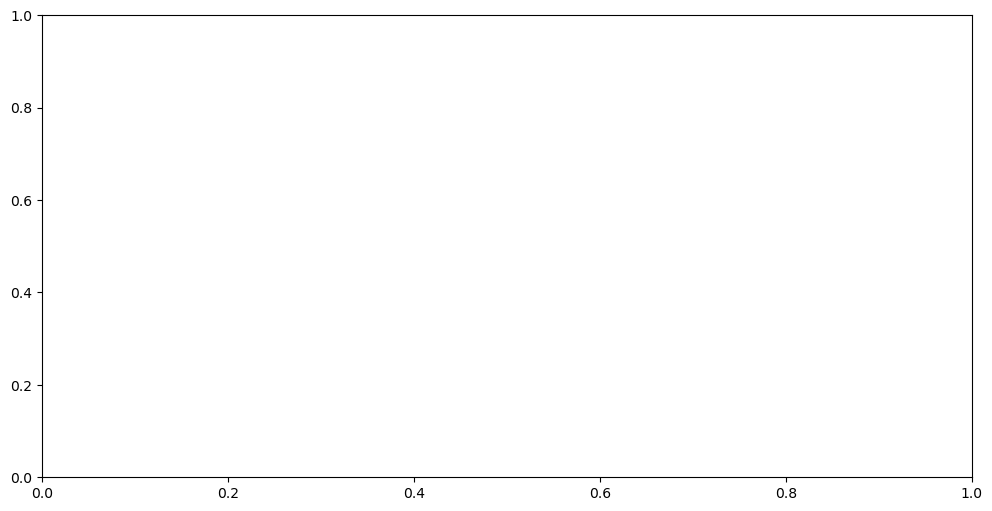

In [12]:
for metric, ylabel in [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1-Score')]:
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (name, color) in enumerate(zip(model_names, colors)):
        vals = [results[name]['per_class_metrics'][cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + i * width - (len(model_names) - 1) * width / 2, vals, width, label=name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Class — CNN vs ResNet-50 vs Swin-T')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Confusion Matrices

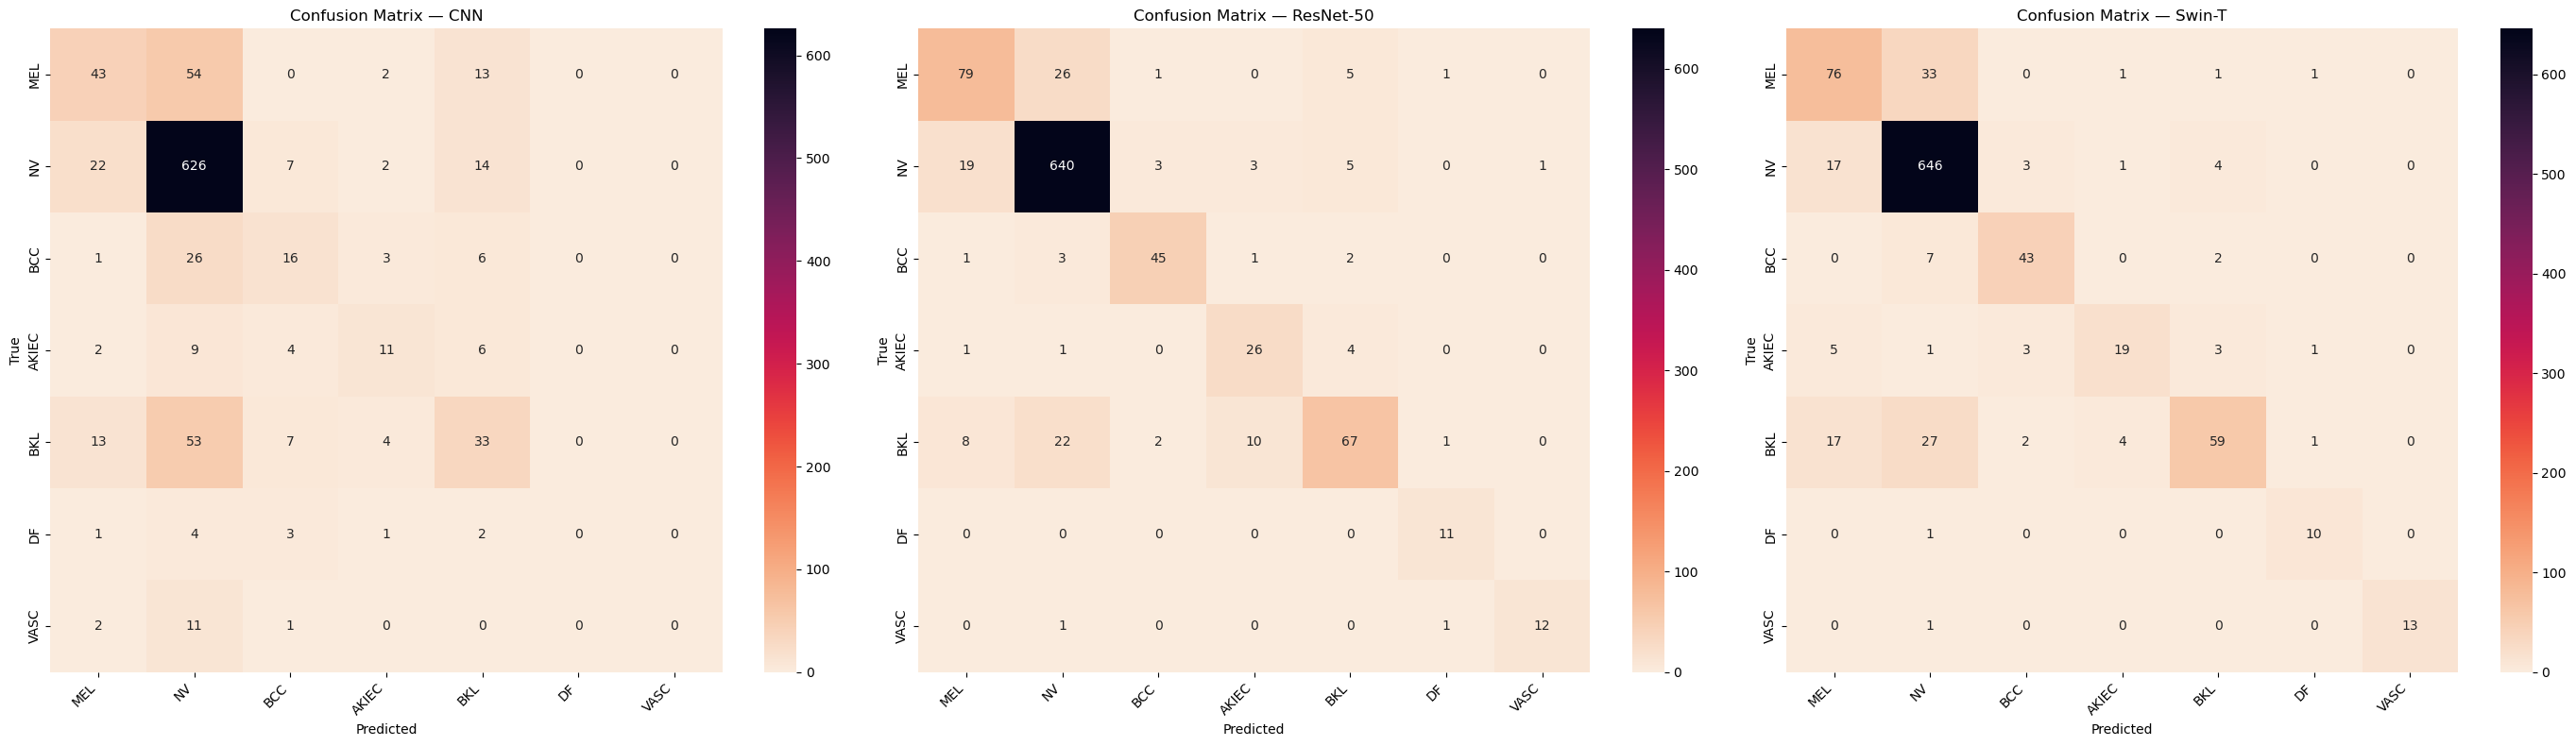

In [10]:
# for name, r in results.items():
#     cm = confusion_matrix(r['labels'], r['preds'])
#     plt.figure(figsize=(10, 8))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
#                 xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
#     plt.title(f'Confusion Matrix — {name}')
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Training Curves

In [11]:
def parse_training_log(log_path):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    pattern = re.compile(
        r'train_loss=([\d.]+)\s+train_acc=([\d.]+)%\s+val_loss=([\d.]+)\s+val_acc=([\d.]+)%'
    )
    with open(log_path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                history['train_loss'].append(float(m.group(1)))
                history['train_acc'].append(float(m.group(2)))
                history['val_loss'].append(float(m.group(3)))
                history['val_acc'].append(float(m.group(4)))
    return history

LOG_PATHS = {name: os.path.join(ROOT, rel_path) for name, rel_path in EVAL_CFG['training_logs'].items()}

histories = {name: parse_training_log(path) for name, path in LOG_PATHS.items()}

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    epochs = range(1, len(h['train_loss']) + 1)
    axs[0].plot(epochs, h['train_loss'], label=f'{name} train')
    axs[0].plot(epochs, h['val_loss'],   label=f'{name} val', linestyle='--')
    axs[1].plot(epochs, h['train_acc'],  label=f'{name} train')
    axs[1].plot(epochs, h['val_acc'],    label=f'{name} val', linestyle='--')

for ax, title, ylabel in zip(
    axs,
    ['Training & Validation Loss', 'Training & Validation Accuracy'],
    ['Loss', 'Accuracy (%)'],
):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/b5ng/private/Dermascope-VLM/results/cnn/best_model/training_log.txt'